In [11]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from matplotlib import pyplot as plt
tqdm.pandas()

In [4]:
df = pd.read_csv('peint_df.csv.gz', compression='gzip')
print(df.columns)

Index(['edge_id', 'sample_id', 'family', 'parent_heavy', 'parent_light',
       'child_heavy', 'child_light', 'parent_name', 'child_name',
       'branch_length', 'parent_heavy_aa', 'parent_light_aa', 'child_heavy_aa',
       'child_light_aa', 'has_indels'],
      dtype='object')


In [7]:
# count number of mutations for transitions
def hamming_dist(a, b):
    return sum(1 for x, y in zip(a, b) if x != y)

df['heavy_muts'] = df.progress_apply(lambda row: hamming_dist(row['parent_heavy_aa'], row['child_heavy_aa']), axis=1)
df['light_muts'] = df.progress_apply(lambda row: hamming_dist(row['parent_light_aa'], row['child_light_aa']), axis=1)

# count number of mutations
df['tot_muts'] = df['heavy_muts'] + df['light_muts']

100%|██████████| 252723/252723 [00:00<00:00, 270636.15it/s]


In [8]:
print(df['tot_muts'].describe())
print(df['branch_length'].describe())

count    252723.000000
mean          8.462051
std           7.986976
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max          96.000000
Name: tot_muts, dtype: float64
count    252723.000000
mean          1.000000
std           1.494952
min           0.000043
25%           0.249458
50%           0.634831
75%           1.347019
max         144.167191
Name: branch_length, dtype: float64


In [10]:
# read the lines inside v1rodriguezCC.txt
with open('v1rodriguezCC.txt', 'r') as f:
    # skip the first line
    next(f)
    lines = f.readlines()

# parse lines into transitions of form (parent, child, branch_length)
transitions = []
for line in lines:
    parent, child, branch_length = line.split()
    transitions.append((parent, child, float(branch_length)))

# for each transition, calculate the number of mutations from parent to child
data = []
for transition in transitions:
    parent, child, branch_length = transition
    n_mutations = hamming_dist(parent, child)
    data.append((parent, child, n_mutations, branch_length))
    
# convert data to pandas dataframe
df = pd.DataFrame(data, columns=['parent', 'child', 'n_mutations', 'branch_length'])

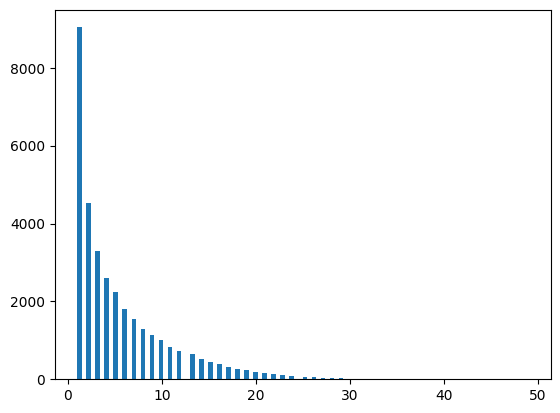

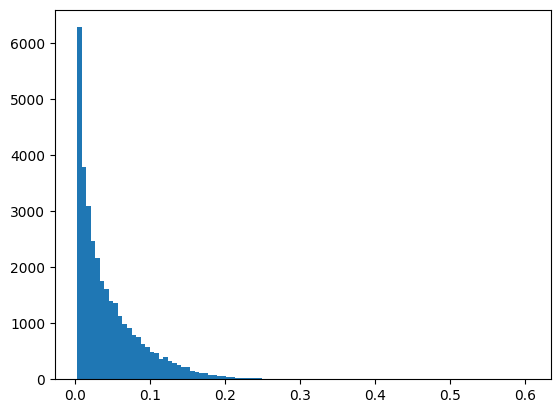

In [12]:
# plot the distribution of n_mutations
plt.hist(df['n_mutations'], bins=100)
plt.show()

# plot the distribution of branch_length
plt.hist(df['branch_length'], bins=100)
plt.show()

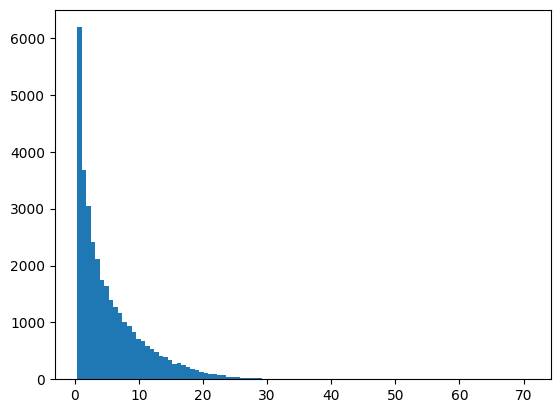

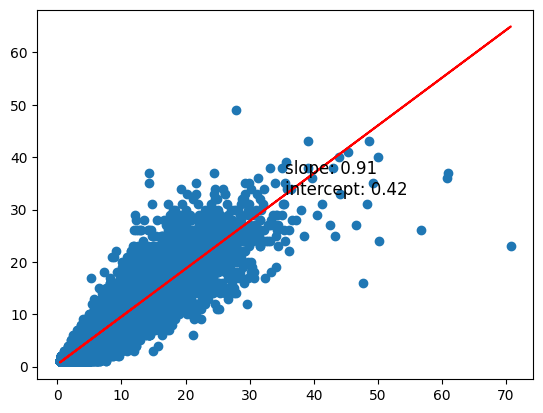

In [17]:
# check if the branch length is approximately equal to the expected number of mutations per site
df['expected_mutations'] = df.apply(lambda row: row['branch_length'] * len(row['parent']), axis=1)
plt.hist(df['expected_mutations'], bins=100)
plt.show()

# plot the distribution of expected_mutations vs n_mutations
plt.scatter(df['expected_mutations'], df['n_mutations'])

# check slope of line of best fit (should be 1)
slope, intercept = np.polyfit(df['expected_mutations'], df['n_mutations'], 1)
plt.plot(df['expected_mutations'], slope * df['expected_mutations'] + intercept, color='red')
# add slope and intercept to plot
plt.text(0.5, 0.5, f'slope: {slope:.2f}\nintercept: {intercept:.2f}', transform=plt.gca().transAxes, fontsize=12)

plt.show()